### Setup Cohere and Pinecone API keys

In [1]:
import os
os.environ['COHERE_API_KEY'] = 'Ie1RBxnNIBE1W5emVUp8y2DeLFg7H8gDEpUUNP7W'
os.environ['PINECONE_API_KEY'] = 'b4f5da78-eed9-45cd-b747-991437c578f7'

### Loading the dataset directly from Huggingface 

In [2]:
from datasets import load_dataset

# load the dataset from huggingface datasets hub
fashion = load_dataset(
    "ashraq/fashion-product-images-small",
    split="train"
)
fashion

c:\Users\Lenovo\miniconda3\envs\E-Commerce_KERNAL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image'],
    num_rows: 44072
})

In [3]:
image=fashion['image']
metadata = fashion.remove_columns("image")

In [5]:
fashion['articleType']

['Shirts',
 'Jeans',
 'Watches',
 'Track Pants',
 'Tshirts',
 'Tshirts',
 'Shirts',
 'Shirts',
 'Socks',
 'Watches',
 'Casual Shoes',
 'Belts',
 'Flip Flops',
 'Handbags',
 'Flip Flops',
 'Shirts',
 'Watches',
 'Tops',
 'Bra',
 'Handbags',
 'Watches',
 'Sandals',
 'Shoe Accessories',
 'Sweatshirts',
 'Deodorant',
 'Formal Shoes',
 'Bracelet',
 'Tshirts',
 'Lipstick',
 'Handbags',
 'Shirts',
 'Tshirts',
 'Shirts',
 'Casual Shoes',
 'Flats',
 'Kurtas',
 'Handbags',
 'Handbags',
 'Watches',
 'Tshirts',
 'Belts',
 'Flats',
 'Watches',
 'Kurtas',
 'Waistcoat',
 'Sports Shoes',
 'Shorts',
 'Briefs',
 'Shirts',
 'Belts',
 'Watches',
 'Formal Shoes',
 'Kurtas',
 'Briefs',
 'Formal Shoes',
 'Tshirts',
 'Tshirts',
 'Shirts',
 'Watches',
 'Tshirts',
 'Sarees',
 'Tshirts',
 'Watches',
 'Handbags',
 'Casual Shoes',
 'Casual Shoes',
 'Perfume and Body Mist',
 'Sports Shoes',
 'Shorts',
 'Casual Shoes',
 'Handbags',
 'Casual Shoes',
 'Shirts',
 'Tshirts',
 'Sweatshirts',
 'Tshirts',
 'Heels',
 'Heels

In [4]:
# convert metadata into a pandas dataframe
metadata = metadata.to_pandas()
shape2=metadata.shape
print(shape2)

(44072, 10)


In [6]:
metadata.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [13]:
len(fashion['image'])

44072

Hybrid Aprroch
1. sparse matrix(BM25) 
2. dense vectors(HUGGING FACE)

### Sparse Vectors

In [7]:
from pinecone_text.sparse import BM25Encoder

bm25 = BM25Encoder()

In [20]:
bm25.encode_documents(metadata['productDisplayName'][0])

{'indices': [23789636,
  1830646559,
  632192512,
  931643408,
  3905155331,
  3828986392],
 'values': [0.14925373134328357,
  0.14925373134328357,
  0.14925373134328357,
  0.14925373134328357,
  0.14925373134328357,
  0.14925373134328357]}

### Dense Vectors

In [9]:
from sentence_transformers import SentenceTransformer

In [10]:
model = SentenceTransformer(
    'sentence-transformers/clip-ViT-B-32',
)
model

c:\Users\Lenovo\miniconda3\envs\E-Commerce_KERNAL\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


SentenceTransformer(
  (0): CLIPModel()
)

In [11]:
model

SentenceTransformer(
  (0): CLIPModel()
)

In [12]:
dense_vec = model.encode([metadata['productDisplayName'][0]])
dense_vec.shape

(1, 512)

### Defining pinecone index

In [14]:
from pinecone import Pinecone,ServerlessSpec

index_name="e-commerce"


pc=Pinecone()


if index_name not in pc.list_indexes().names():
    pc.create_index(
        index_name,
        dimension=512,
        metric='dotproduct',
        spec=ServerlessSpec(cloud='aws', region='us-east-1') 
    ) 
   

In [15]:
index=pc.Index(index_name)
index.describe_index_stats() 


{'dimension': 512,
 'index_fullness': 0.0,
 'namespaces': {'': {'vector_count': 17600}},
 'total_vector_count': 17600}

In [16]:
index.describe_index_stats().total_vector_count

17600

### Upsert Documents

In [17]:
from tqdm.auto import tqdm

batch_size = 200

if index.describe_index_stats().total_vector_count == 0:

    for i in tqdm(range(0, len(fashion), batch_size)):#400
        # find end of batch
        i_end = min(i+batch_size, len(fashion))#600
        # extract metadata batch
        meta_batch = metadata.iloc[i:i_end]# 400 600
        print(len(meta_batch))
        meta_dict = meta_batch.to_dict(orient="records")
        # concatinate all metadata field except for id and year to form a single string
        meta_batch = [" ".join(x) for x in meta_batch.loc[:, ~meta_batch.columns.isin(['id', 'year'])].values.tolist()]
        # extract image batch
        img_batch = image[i:i_end]
        print(len(img_batch))
        # create sparse BM25 vectors
        sparse_embeds = bm25.encode_documents([text for text in meta_batch])
        # create dense vectors
        dense_embeds = model.encode(img_batch).tolist()
        # create unique IDs
        ids = [str(x) for x in range(i, i_end)]

        upserts = []
        # loop through the data and create dictionaries for uploading documents to pinecone index
        for _id, sparse, dense, meta in zip(ids, sparse_embeds, dense_embeds, meta_dict):
            upserts.append({
                'id': _id,
                'sparse_values': sparse,
                'values': dense,
                'metadata': meta
            })
        # upload the documents to the new hybrid index
        index.upsert(upserts)

# show index description after uploading the documents
index.describe_index_stats()

{'dimension': 512,
 'index_fullness': 0.0,
 'namespaces': {'': {'vector_count': 17600}},
 'total_vector_count': 17600}

### Querying

In [28]:
query = "soft green color topwear"

### Creating Embeding for query

In [29]:
sparse = bm25.encode_queries(query)
dense = model.encode(query).tolist()

In [30]:
result = index.query(
    top_k=14,
    vector=dense,
    sparse_vector=sparse,
    include_metadata=True
)

In [31]:
result

{'matches': [{'id': '3122',
              'metadata': {'articleType': 'Tops',
                           'baseColour': 'Green',
                           'gender': 'Women',
                           'id': 59405.0,
                           'masterCategory': 'Apparel',
                           'productDisplayName': 'Tokyo Talkies Women Green '
                                                 'Top',
                           'season': 'Fall',
                           'subCategory': 'Topwear',
                           'usage': 'Casual',
                           'year': 2012.0},
              'score': 29.7730522,
              'values': []},
             {'id': '4207',
              'metadata': {'articleType': 'Tops',
                           'baseColour': 'Green',
                           'gender': 'Women',
                           'id': 49639.0,
                           'masterCategory': 'Apparel',
                           'productDisplayName': 'Mineral Women Lime G

### For fetching images using returned product ids

In [32]:
imgs = [image[int(r["id"])] for r in result["matches"]]
imgs

[<PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>]

### Function for displaying images

In [33]:
import matplotlib.pyplot as plt

def display_images(image_batch):
    for img in image_batch:
        plt.imshow(img)
        # plt.axis('off')  # Hide the axes
        plt.show()


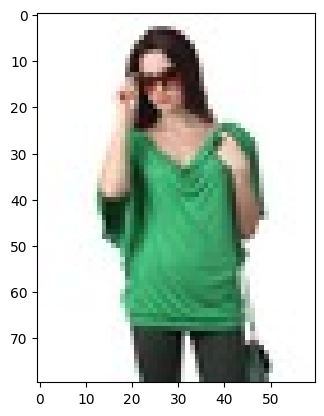

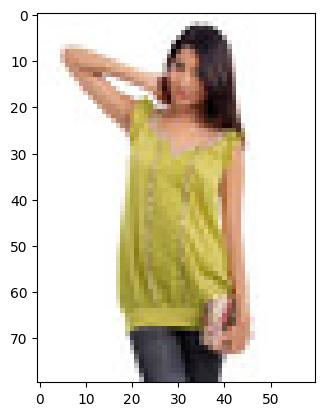

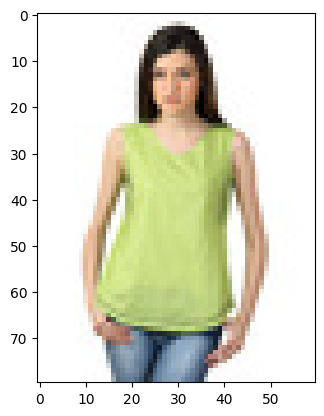

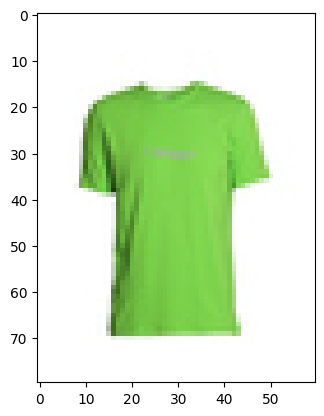

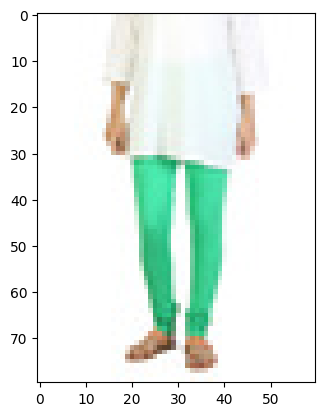

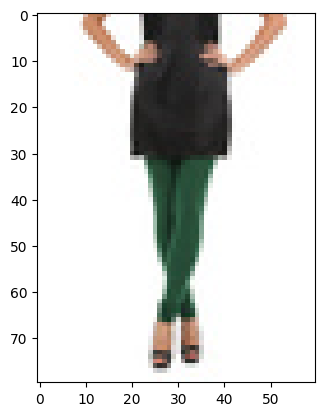

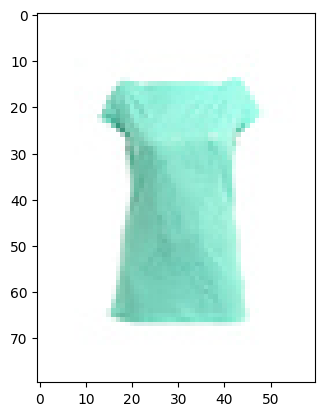

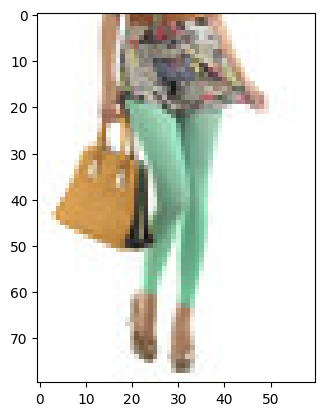

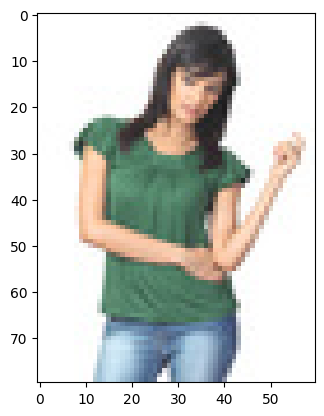

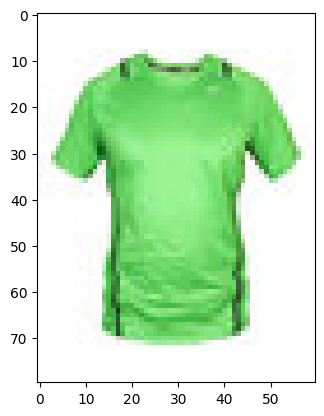

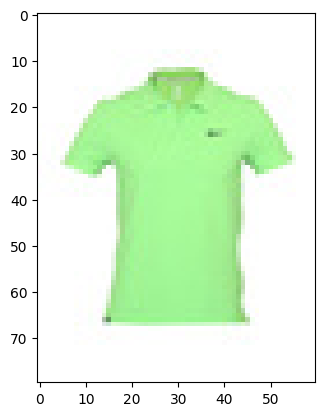

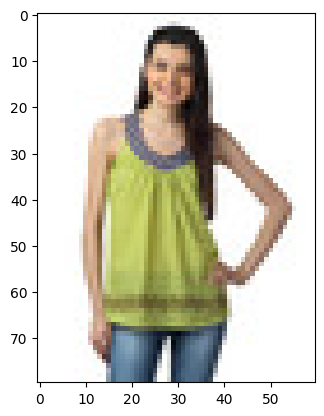

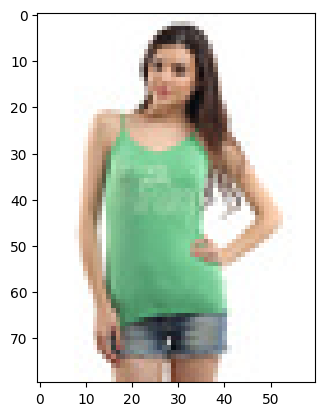

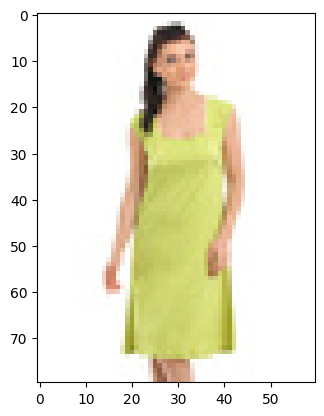

In [34]:
display_images(imgs)

### Implimenting Hybrid Search for better results 
 Seting up an hyperparameter Alpha value ranges between 0 and 1|
 when the value is more towards 1 the results will be more prone towards dense vectors 

In [38]:
def hybrid_scale(dense, sparse, alpha: float):
    if alpha < 0 or alpha > 1:
        raise ValueError("Alpha must be between 0 and 1")
    # scale sparse and dense vectors to create hybrid search vecs
    hsparse = {
        'indices': sparse['indices'],
        'values':  [v * (1 - alpha) for v in sparse['values']]
    }
    hdense = [v * alpha for v in dense]
    return hdense, hsparse

In [45]:
# scale sparse and dense vectors
# you can setup alpha to be any value between 0 and 1
hdense, hsparse = hybrid_scale(dense, sparse, alpha=0.0)

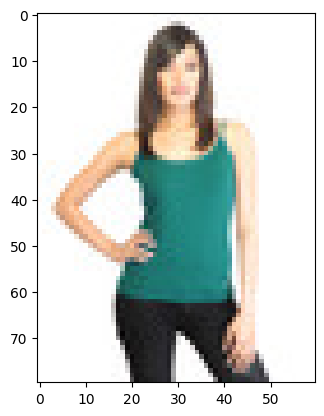

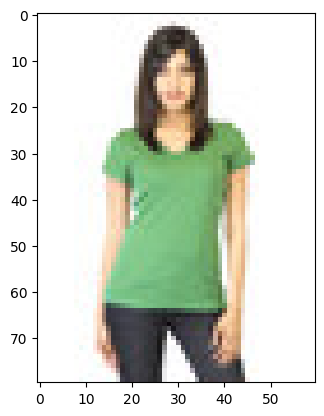

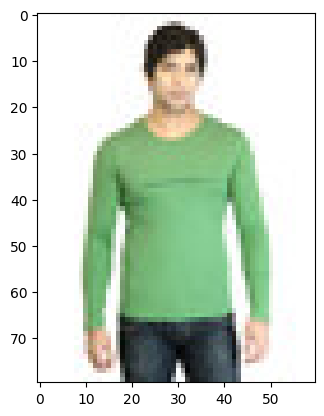

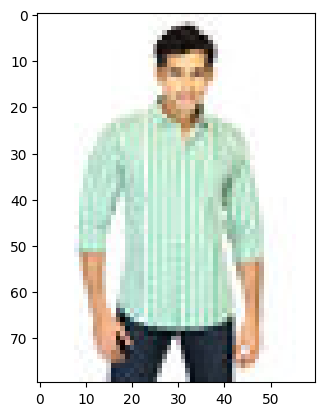

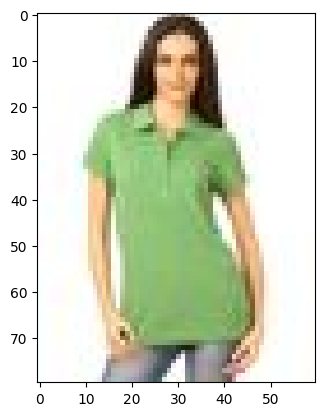

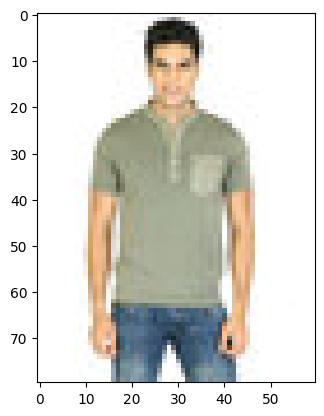

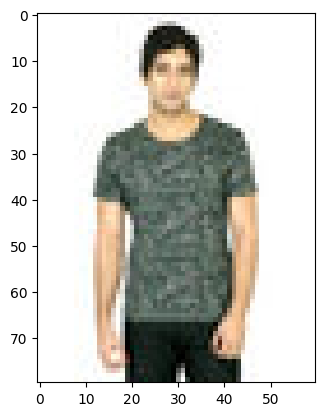

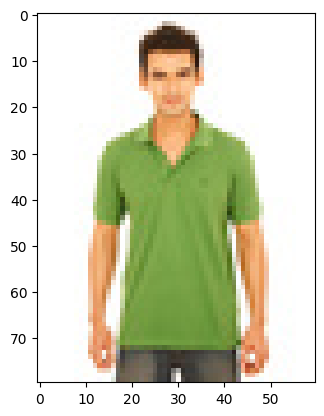

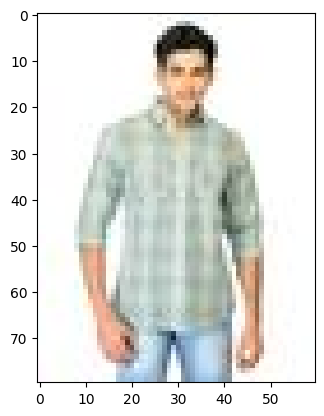

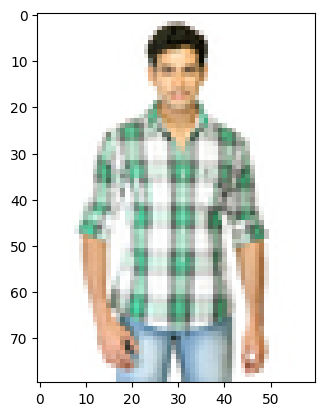

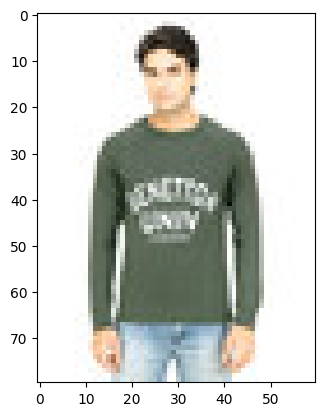

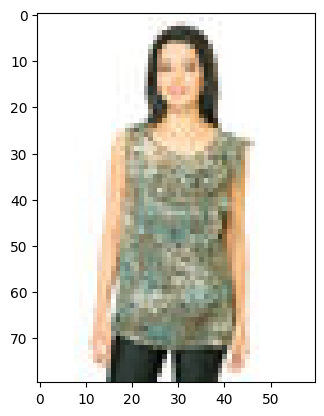

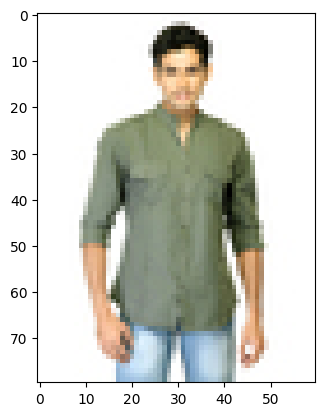

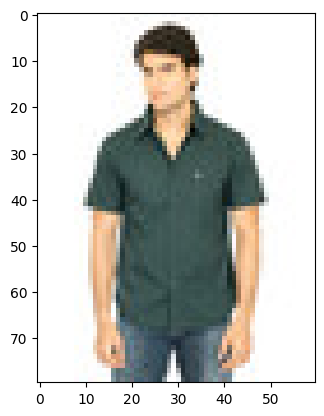

In [46]:
result = index.query(
    top_k=14,
    vector=hdense,
    sparse_vector=hsparse,
    include_metadata=True
)
# used returned product ids to get images
imgs = [image[int(r["id"])] for r in result["matches"]]
# display the images
display_images(imgs)

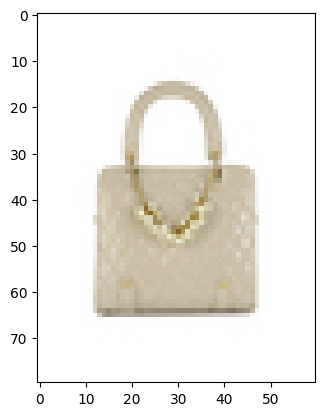

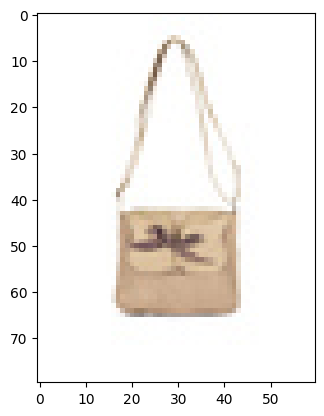

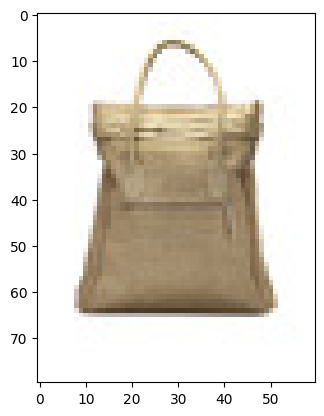

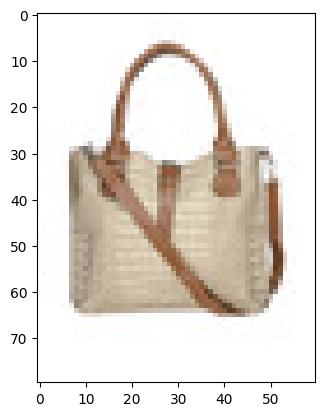

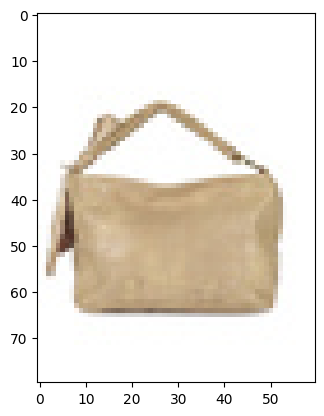

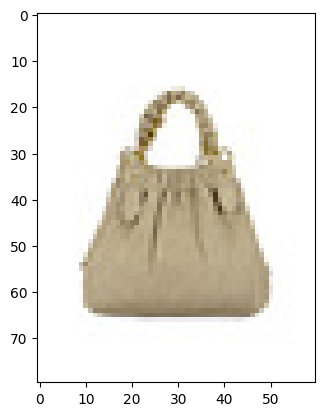

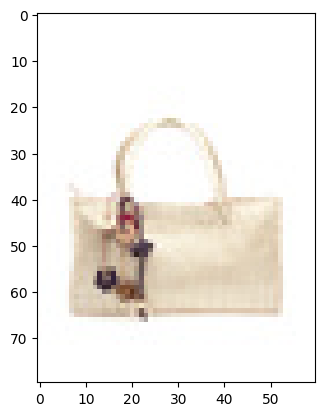

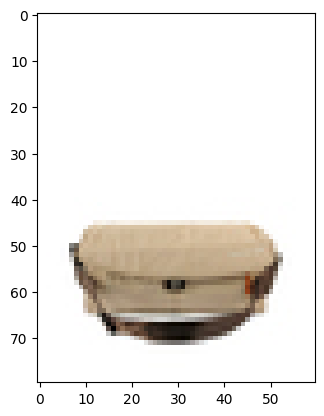

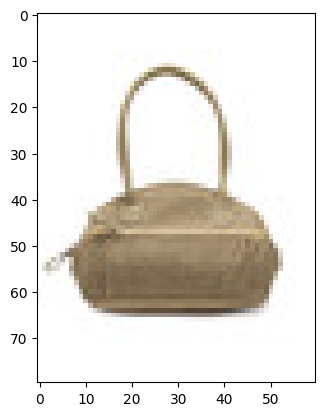

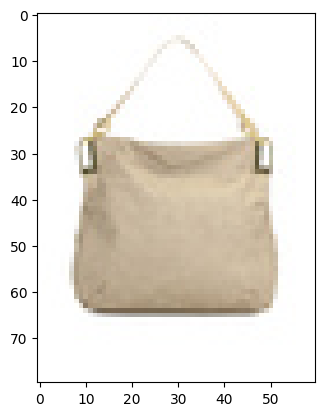

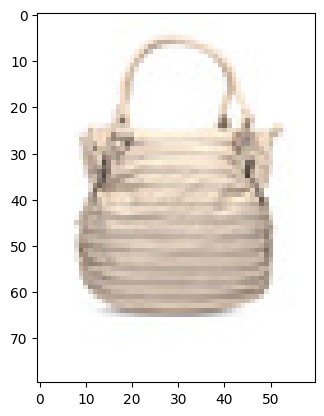

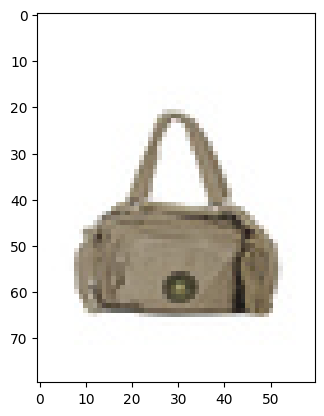

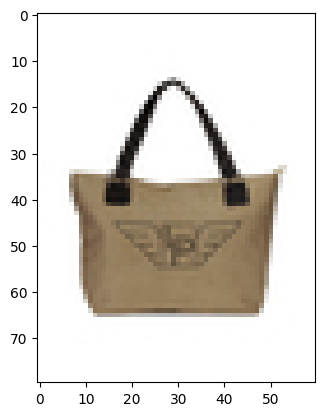

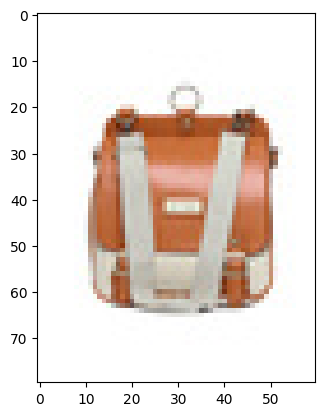

In [47]:
query = "small beige handbag for women"
# create sparse and dense vectors
sparse = bm25.encode_queries(query)
dense = model.encode(query).tolist()
# scale sparse and dense vectors - keyword search first
hdense, hsparse = hybrid_scale(dense, sparse, alpha=0)
# search
result = index.query(
    top_k=14,
    vector=hdense,
    sparse_vector=hsparse,
    include_metadata=True
)
# used returned product ids to get images
imgs = [image[int(r["id"])] for r in result["matches"]]
# display the images
display_images(imgs)

### Providing metadata for enhanching results

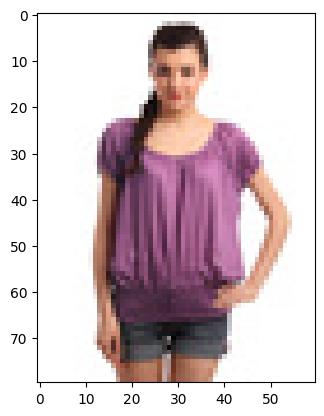

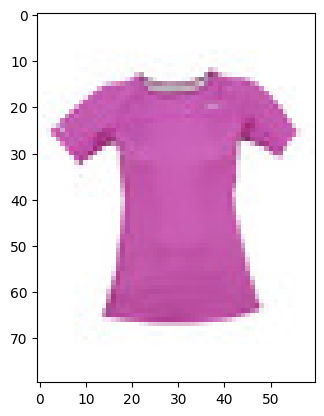

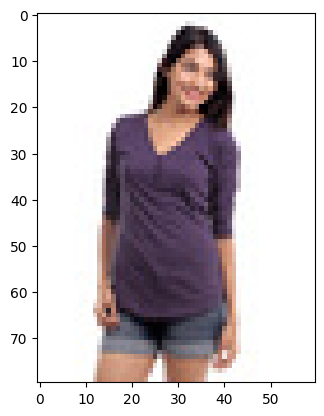

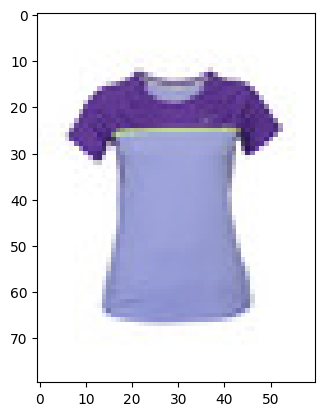

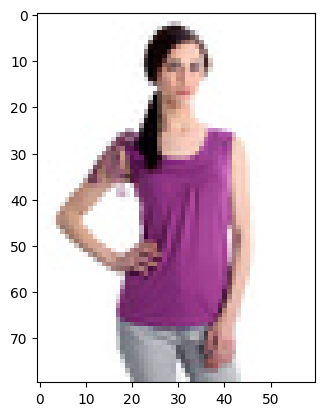

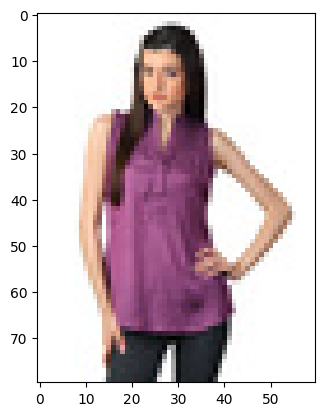

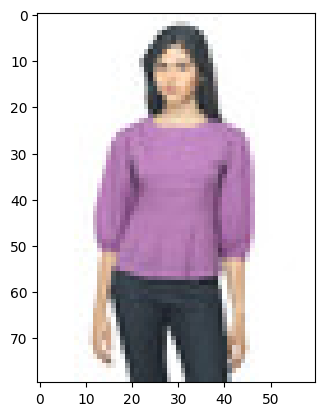

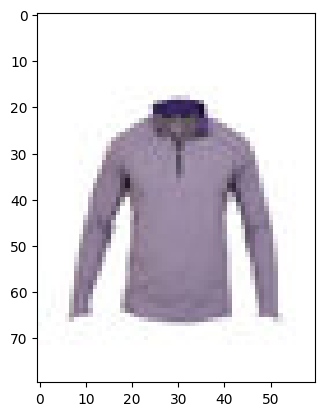

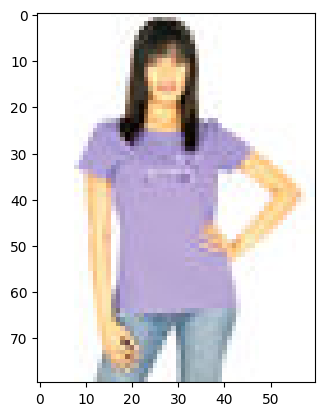

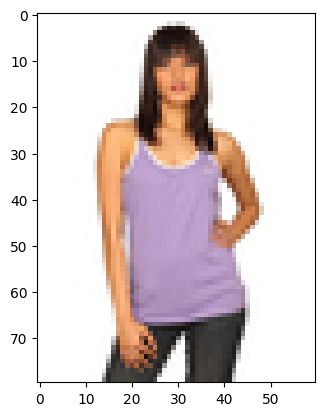

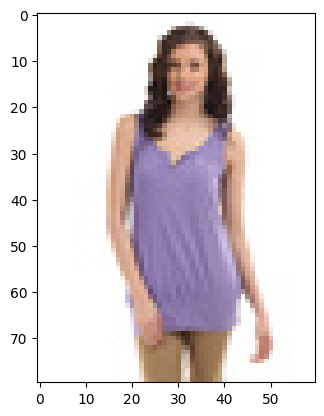

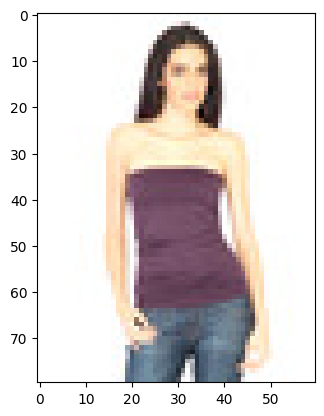

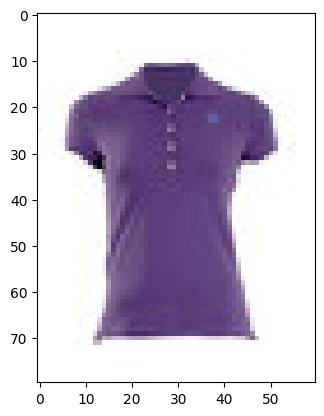

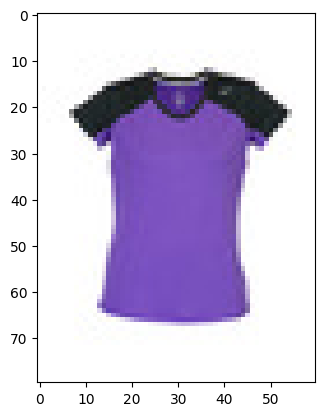

In [51]:
query = "soft purple topwear"
# create the sparse vector
sparse = bm25.encode_queries(query)
# now create the dense vector using the image
dense = model.encode(query).tolist()
# scale sparse and dense vectors
hdense, hsparse = hybrid_scale(dense, sparse, alpha=0.6)
# search
result = index.query(
    top_k=14,
    vector=hdense,
    sparse_vector=hsparse,
    include_metadata=True,
    filter={"baseColour": "Purple",
            "subCategory":"Topwear"
            }  # add to metadata filter
)
# used returned product ids to get images
imgs = [image[int(r["id"])] for r in result["matches"]]
# display the images
display_images(imgs)